# 06. PyTorch Transfer Learning

Transfer learning involves taking the parameters of what one model has learned on another dataset and applying to our own problem.

* Pretrained model = foundation models

In [1]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.6.0
0.21.0


Now we've got the versions of torch and torchvision, we're after, let's import the code we've written in previous sections so that we don't have to write it all again.

In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] torchinfo not found, installing...")
    %%pip install torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't exist
try:
    from going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] going_modular not found, downloading...")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

[INFO] going_modular not found, downloading...
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Counting objects: 100% (1534/1534), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 4393 (delta 1458), reused 1399 (delta 1399), pack-reused 2859 (from 2)
Receiving objects: 100% (4393/4393), 650.71 MiB | 7.94 MiB/s, done.
Resolving deltas: 100% (2660/2660), done.
mv: rename pytorch-deep-learning/going_modular to ./going_modular: Directory not empty


In [3]:
# Setup device agnostic code
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

[INFO] Using device: mps


## 1. Get data

We need our pizza, steak, sushi data to build a transfer learning model on.

In [4]:
import os
import zipfile

from pathlib import Path

import requests

# Setup data path
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"    # images from a subset of classes from the Food101 dataset

# If the image folder doesn't exist, download and unzip the dataset
if not image_path.is_dir():
    print(f"{image_path} directory exists, skipping download.")
else:
    print(f"Did you find {image_path}, downloading it...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download the dataset
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        url = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
        print(f"[INFO] Downloading {url}...")
        r = requests.get(url)
        f.write(r.content)
        
    # unzip pizza_steak_sushi.zip
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print(f"[INFO] Downloaded and unzipped {image_path} dataset.")
        zip_ref.extractall(image_path)
            
    # Remove the zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

Did you find data/pizza_steak_sushi, downloading it...
[INFO] Downloading https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Downloaded and unzipped data/pizza_steak_sushi dataset.


In [5]:
# Setup directory path
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## 2. Create Datasets and DataLoaders

Now we've got some data, want to turn it into PyTorch DataLoaders.

To do so, we can use `data_setup.py` and the `create_dataloaders()` function we made in 05. PyTorch Going Module

There's one thing we have to think about wehn loading: how to **transform** it?

And with `torchvision` 0.13+ there's two ways to do this:

1. Manually created transforms - you define what transforms you want your data to go through.
2. Automatically created transforms - the transforms for your data are defined by the model you'd like to use.

Important point: when using a pretrained model, it's important that the data (including your custom data) that you pass through it is **transformed** in the same way that the data the model was trained on.

In [6]:
from going_modular.going_modular import data_setup

In [7]:
import torchvision
torchvision.__version__

'0.21.0'

### 2.1 Creating a transform for `torchvision.models` (manual creation)

`torchvision.models` contains pretrained models (models ready for transfer learning) right within `torchvision`

> All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGR images of shape (3 xH x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of l0, 1fand then normalizedusing mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225l. You can use the followina transform to normalize.

In [8]:
from torchvision import transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 (heights x widths)
    transforms.ToTensor(),  # get images into range [0, 1]
    normalize   # make sure imsages have same distribution as ImageNet
])

In [9]:
from going_modular.going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x12aeb2570>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Creating a transform for `torchvision.models` (auto creation)

As of `torchvision` v0.13+ there is now support for automatic data transform creation based on the pretrained model weights you're using.

In [10]:
import torchvision
torchvision.__version__

'0.21.0'

In [11]:
# Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT    # 'DEFAULT' = best available weights
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [12]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [13]:
# Create DataLoaders using automatic transforms
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=auto_transforms,
    batch_size=32
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x12af384d0>,
 ['pizza', 'steak', 'sushi'])

## 3. Getting a pretrained model

There are various places to get a pretrained model, such as:
1. PyTorch domain libraries
2. Libraries like `timm` (torch image models)
3. HuggingFace Hub (for plent of different models)
4. Paperswitchcode (for models across different problem spaces/domains)

### 3.1 Which pretrained model should you use?
*Experiment, experiment, experiment!*

The whole idea of transfer learning: take an already well-performing mode lfrom a problem space similar to your own and then customize to your own problem.

Three things to consider:
1. Speed - how fast does it run?
2. Size - how big is the model?
3. Performance - how well does it go on your chosen problem (e.g. how well does it classify food images? for FoodVision Mini)?

Where does the model live?

Is it on device? (like a self-driving car)

Or does it live on a server?

Looking at https://pytorch.org/vision/main/models.html#table-of-all-available-classification-weights

Which model should we choose?

For our case (deploying FoodVision Mini on a mobile device), it looks like EffNetB0 is one of our best options in terms performance vs size.

However, in light of The Bitter Lesson, if we had infinite compute, we'd likely pick the biggest model + most parameters + most general we could 

- http://www.incompleteideas.net/incldeas/BitterLesson.htm!

### 3.2 Setting up a pretrained model

In [14]:
# OLD method of creating a pretrained model (prior to torchvision v0.13)
model = torchvision.models.efficientnet_b0(pretrained=True)

# New method of creating a pretrained model (torchvision v0.13+)
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT    # ".DEFAULT" = best available weights
model = torchvision.models.efficientnet_b0(weights=weights)
model

/Users/whiteknight/Develop/PytorchTraining/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/whiteknight/Develop/PytorchTraining/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [15]:
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [16]:
model.avgpool

AdaptiveAvgPool2d(output_size=1)

In [17]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

### 3.3 Getting a summary of our model with `torchinfo.summary()`

In [18]:
# Print with torchinfo
from torchinfo import summary

summary(model=model,
        input_size=(1, 3, 224, 224),    # example of [batch_size, channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"],
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

### 3.4 Freezing the base model and changing the output layer to suit our needs

With a feature extractor model, typically you will "freeze" the base layers of a pretrained/foundation model and update the output layers to suit your own problem.

In [19]:
# Freeze all of the base layers in EfficientNetB0
for param in model.features.parameters():
    param.requires_grad = False

In [21]:
len(class_names)

3

In [22]:
# Update the classifier head of our model to suit our problem
from torch import nn

torch.manual_seed(42)  # Set a random seed for reproducibility

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),  # Dropout layer with a probability of 0.2
    nn.Linear(in_features=1280, out_features=len(class_names))  # Linear layer with in_features=1280 and out_features=len(class_names)
).to(device)  # Move the model to the device (GPU or CPU)

In [23]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

In [24]:
summary(model=model,
        input_size=(1, 3, 224, 224),    # example of [batch_size, channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"],
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

## 4. Train model

In [26]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()  # Cross-entropy loss function
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)  # Adam optimizer with learning rate of 0.001

In [30]:
# Import train function
from going_modular.going_modular import engine

# Set the manual seed
torch.manual_seed(42)  # Set a random seed for reproducibility

# Start the timer
from timeit import default_timer as timer
start_time = timer()  # Start the timer
# Train the model
results = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=5,  # Number of epochs to train
    device="mps"  # Device to use (GPU or CPU)
)
# Stop the timer
end_time = timer()  # Stop the timer
# Calculate the time taken to train the model
total_time = end_time - start_time  # Calculate the time taken
print(f"[INFO] Total training time: {total_time:.3f} seconds")  # Print the time taken

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5160 | train_acc: 0.9180 | test_loss: 0.5679 | test_acc: 0.8561
Epoch: 2 | train_loss: 0.4624 | train_acc: 0.9336 | test_loss: 0.5263 | test_acc: 0.8759
Epoch: 3 | train_loss: 0.4659 | train_acc: 0.9258 | test_loss: 0.5184 | test_acc: 0.8958
Epoch: 4 | train_loss: 0.4760 | train_acc: 0.8281 | test_loss: 0.4802 | test_acc: 0.8551
Epoch: 5 | train_loss: 0.4182 | train_acc: 0.9453 | test_loss: 0.4911 | test_acc: 0.8561
[INFO] Total training time: 292.157 seconds


In [ ]:
results

## 5. Evaluate model by plotting loss curves

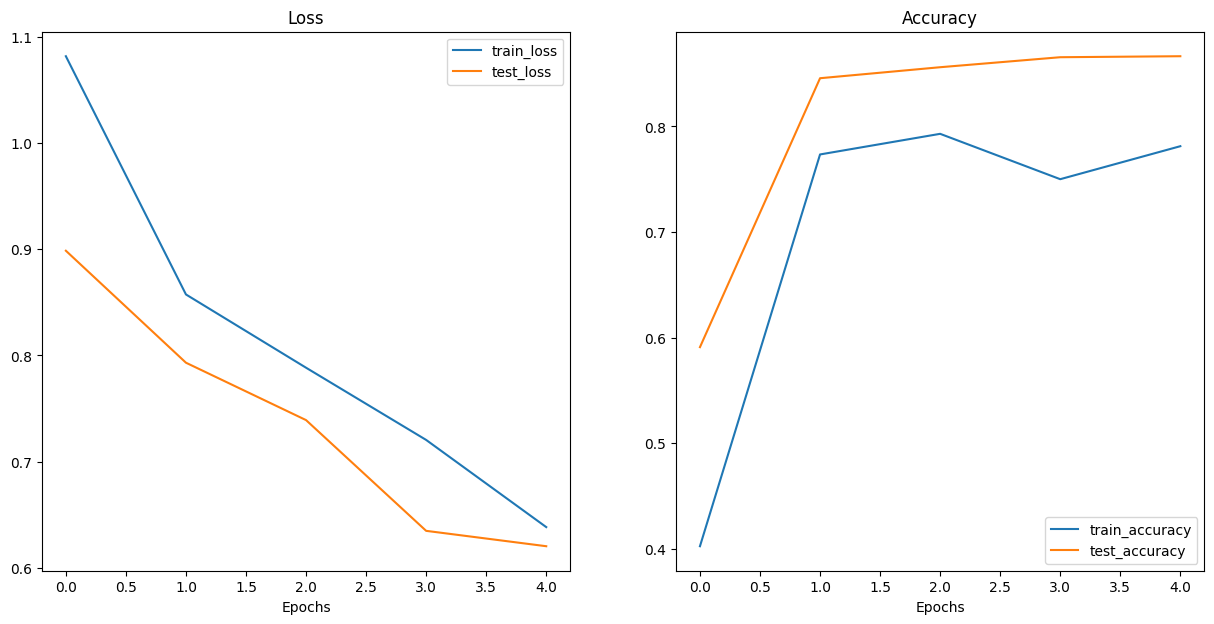

In [29]:
try:
    from helper_functions import plot_loss_curves
except:
    print(f"[INFO] Counldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
        r = requests.get(url)
        f.write(r.content)
    from helper_functions import plot_loss_curves
    
# Plot the loss curves of our model
plot_loss_curves(results)  # Plot the loss curves of our model

What does our loss curves look like in terms of the ideal loss curve?

## 6. Make predictions on images from the test set

Let's adhere to the data explorer's motto of *visualize, visualize, visualize*!

And make some qualitiative predictions on our test set.

Some things to keep in mind when making predictions/inference on test data/custom data.

We have to make sure that our test/custom data is:
* Same shape - images need to be same shape as model was trained on
* Same datatype - custom data should be in the same data type
* Same device - custom data/test data should be on the same device as the model
* Same transform - if you've transformed your custom data, ideally you will transform the best data and custom data the same

To do all of this automatically, let's create a function called `pred_and_plot_image()`:

The function will be similar to the one here: https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function

1. Take in a trained model, a list of class name, a filepath to a target image, an image size, a transform and a target device
2. Open the image with `PIL.Image.Open()`
3. Create a transform if one doesn't exist
4. Make sure the model is on the target device
5. Turn the model to `model.eval()` mode to make sure it's ready for inference (this will turn off things like `nn.Dropout()`)
6. Transform the target image and make sure its dimensionality is suited for the model (this mainly relates to batch size)
7. Make a prediction on the image by passing to the model
8. Convert the model's output logits to prediction probabilities using `torch.softmax()`
9. Convert model's prediction probabilities to prediction labels using `torch.argmax()`
10. Plot the image with `matplotlib` and set the title to the prediction label from step 9 and prediction probability from step 8

In [31]:
from typing import List, Tuple

from PIL import Image

# 1. Take in a trained model...
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms.Compose = None,
                        device: torch.device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Takes in a trained model, an image path, a transform and a list of class names
    and returns the predicted class and the probability of the prediction.
    """
    # 2. Open the image with PIL
    img = Image.open(image_path)
    
    # 3. Create a transform if one doesn't exist
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    ### Predict on image ###
    # 4. Make sure the model is on the target device
    model.to(device)
    
    # 5. Turn on inference mode and eval mode
    model.eval()
    with torch.inference_mode():
        # 6. Transform the image and add an extra batch dimension
        transformed_image = image_transform(img).unsqueeze(dim=0)   # [batch_size, channels, height, width]
        
        # 7. Make a prediction on the transformed image by passing it to the model (also ensure the model is on the target device)
        target_image_pred = model(transformed_image.to(device))
    
    # 8. Convert the target image prediction probabilities to class probabilities
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    
    # 9. Convert the model's pred probs to pred labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    # 10. Plot image with predicted label and probability
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label.item()]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

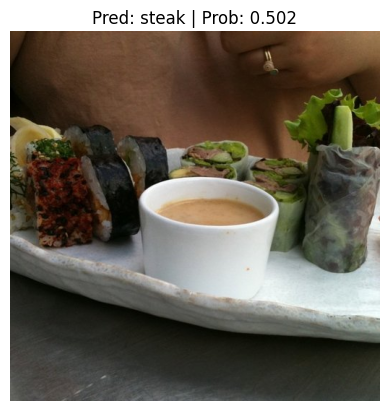

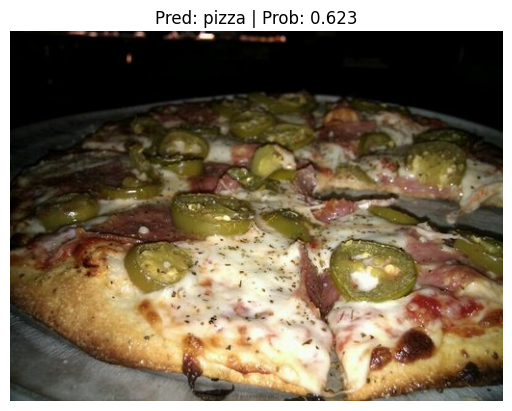

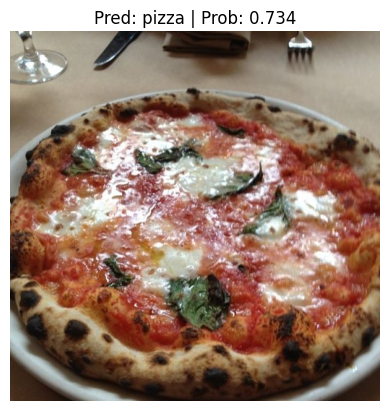

In [40]:
# Get a random list of image paths from the test set
import random
num_images_to_predict = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))  # Get all jpg images in the test directory
random_test_image_paths = random.sample(test_image_path_list, num_images_to_predict)  # Get a random sample of image paths

# make predictions on and plot the images
for image_path in random_test_image_paths:
    pred_and_plot_image(
        model=model,
        image_path=str(image_path),
        class_names=class_names,
        transform=auto_transforms,
        device="mps"
    )

### 6.1 Making predictions on a custom image

Let's make a prediction on the pizza dad image - https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-data.jpeg

In [43]:
# Download the image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"  

# Download the image if it doesn't exist
if not custom_image_path.is_file():
    print(f"Downloading {custom_image_path}...")
    with open(custom_image_path, "wb") as f:
        url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"
        r = requests.get(url)
        f.write(r.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

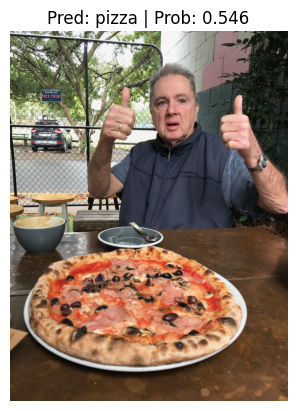

In [46]:
# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)